In [70]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.utils import get_custom_objects
from tensorflow.keras.models import load_model

import os
os.environ["CUDA_VISIBLE_DEVICES"] = "MIG-166d7783-762d-5f61-b31c-549eb4e0fba0" 

def load_model_wrapper(model_h5):
    custom_objects={"tf": tf}
    get_custom_objects().update(custom_objects)
    model=load_model(model_h5)
    #print("got the model")
    #model.summary()
    return model

accessibility_model="/mnt/lab_data2/anusri/chrombpnet/results/chrombpnet/DNASE_PE/K562/nautilus_runs_may18/K562_05.13.2022_bias_128_4_1234_0.5_fold_0/chrombpnet_model/chrombpnet_wo_bias.h5"
model = load_model_wrapper(accessibility_model)

In [92]:
import pyfaidx
from tangermeme.utils import one_hot_encode
from tangermeme.utils import random_one_hot
from tangermeme.ersatz import substitute
import one_hot

SEQLEN=2114

pos0=5271075
allele='G'
altallele='A'
chrm = 'chr11'

# pos0=155271607
# allele='A'
# altallele='C'
# chrm = 'chr1'

# pos0=5271230
# allele='G'
# altallele='A'
# chrm = 'chr11'

# misses a motif enformer
# pos0=5271228
# allele='G'
# altallele='A'
# chrm = 'chr11'

genome = pyfaidx.Fasta("/mnt/lab_data2/anusri/chrombpnet/reference/male.hg19.fa")
refseq = genome[chrm][pos0-SEQLEN//2:pos0].seq.upper() + allele + genome[chrm][pos0+1:pos0+SEQLEN//2].seq.upper()
altseq = genome[chrm][pos0-SEQLEN//2:pos0].seq.upper() + altallele + genome[chrm][pos0+1:pos0+SEQLEN//2].seq.upper()

refX = one_hot.dna_to_one_hot(refseq)
altX = one_hot.dna_to_one_hot(altseq)

import os
os.environ["CUDA_VISIBLE_DEVICES"] = "MIG-166d7783-762d-5f61-b31c-549eb4e0fba0" 
os.environ["WORLD_SIZE"] = "1"

In [93]:
refpreds = model(refX.squeeze()[None,:,:])
altpreds = model(altX.squeeze()[None,:,:])

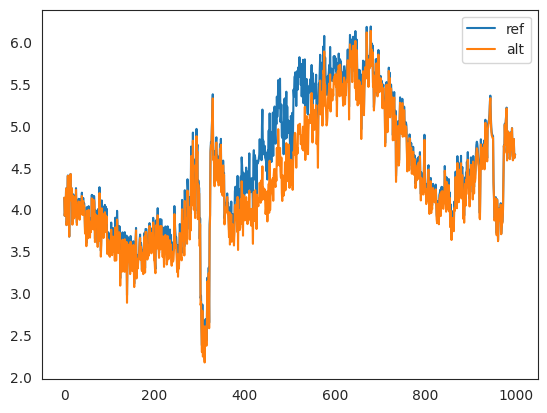

In [94]:
import matplotlib.pyplot as plt
plt.plot(refpreds[0][0,:], label="ref")
plt.plot(altpreds[0][0,:], label="alt")
plt.legend()


In [95]:

class ChromBPNet:
    def __init__(self, model):
        self._model = model

    def predicton_batch(self, inputs):
        return self._model(inputs)
      
    @tf.function
    def contribution_input_profile_grad(self, input_sequence,
                          target_mask, output_head='human'):
        input_sequence = input_sequence[tf.newaxis]
        
        with tf.GradientTape() as tape:
          tape.watch(input_sequence)
          prediction = tf.reduce_sum(
              self._model(input_sequence)[0]) / 1000
         
        input_grad = tape.gradient(prediction, input_sequence) * input_sequence
        input_grad = tf.squeeze(input_grad, axis=0)
        return tf.reduce_sum(input_grad, axis=-1)
        
    @tf.function
    def contribution_input_count_grad(self, input_sequence,
                          target_mask, output_head='human'):
        input_sequence = input_sequence[tf.newaxis]
        
        with tf.GradientTape() as tape:
          tape.watch(input_sequence)
          prediction = self._model(input_sequence)[1]
        
        input_grad = tape.gradient(prediction, input_sequence) * input_sequence
        input_grad = tf.squeeze(input_grad, axis=0)
        return tf.reduce_sum(input_grad, axis=-1)

In [96]:
cmodel = ChromBPNet(model)

In [97]:
import numpy as np
tensor_refX = tf.convert_to_tensor(refX.squeeze()[None,:,:], dtype=tf.float32)
refcontribs = cmodel.contribution_input_count_grad(tensor_refX[0], None)
refcontribs1 = np.transpose(refX.squeeze())[None,:,:] * refcontribs[None,None,:]

tensor_altX = tf.convert_to_tensor(altX.squeeze()[None,:,:], dtype=tf.float32)
altcontribs = cmodel.contribution_input_count_grad(tensor_altX[0], None)
altcontribs1 = np.transpose(altX.squeeze())[None,:,:] * altcontribs[None,None,:]

max_v1 = tf.reduce_max(tf.concat([refcontribs,altcontribs], axis=-1) )


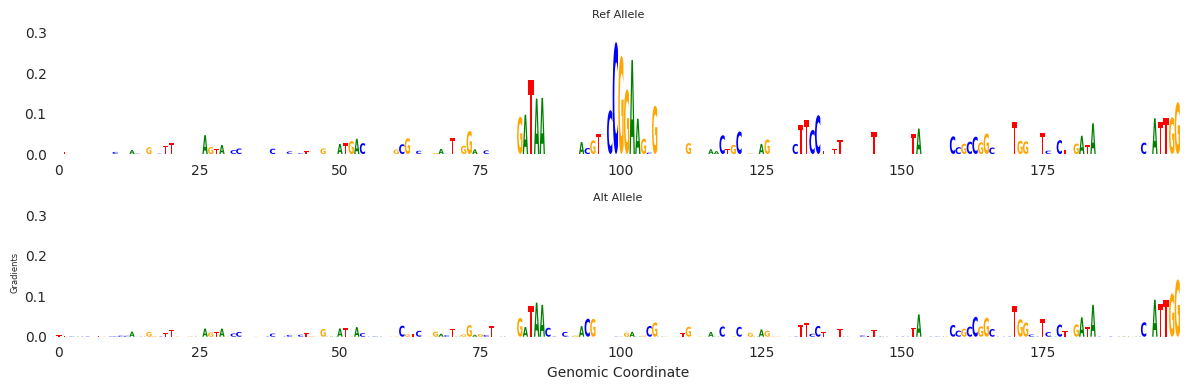

In [98]:
import matplotlib.pyplot as plt
import seaborn; seaborn.set_style('white')
from tangermeme.plot import plot_logo
import torch 
# import tensorflow.python.ops.numpy_ops.np_config as np_config
# np_config.enable_numpy_behavior()


fig, axs = plt.subplots(nrows=2, ncols=1, figsize=(12, 4)) # Creates 3 vertically stacked subplots

plot_logo(refcontribs1[0,:,2114//2-100:2114//2+100].numpy(), ax=axs[0])
plot_logo(altcontribs1[0,:,2114//2-100:2114//2+100].numpy(), ax=axs[1])
axs[0].set_title("Ref Allele", fontsize=8)
axs[1].set_title("Alt Allele", fontsize=8)

axs[1].set_xlabel("Genomic Coordinate")
axs[1].set_ylabel("Gradients", fontsize=6)
# plt.title("Ref Allele")
axs[0].set_ylim((0,max_v1))
axs[1].set_ylim((0,max_v1))
plt.tight_layout()


title="chrombpnet_"+chrm+"_"+str(pos0)+"_"+allele+"_"+altallele
plt.savefig("subfigs/"+title+".pdf", transparent=True, dpi=300)

